# Task 2: Flowchart Games – Decision Trees

## Aim:
### To grasp the intuitive decision-making process of Decision Trees, likened to a “20 Questions” game. Learners will understand how trees recursively split data based on features to arrive at a prediction, and how to interpret their structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

import seaborn as sns

In [2]:
# Generate synthetic data for Decision Tree
np.random.seed(42)

# Class 0: Not Buy (e.g., Younger, Lower Income)
X_dt0 = np.random.normal(loc=[30, 40000], scale=[8, 10000], size=(60, 2))
y_dt0 = np.zeros(60)

# Class 1: Buy (e.g., Older, Higher Income)
X_dt1 = np.random.normal(loc=[50, 70000], scale=[10, 15000], size=(60, 2))
y_dt1 = np.ones(60)

# Combine data
X_dt = np.vstack((X_dt0, X_dt1))
y_dt = np.hstack((y_dt0, y_dt1))

df_dt = pd.DataFrame(X_dt, columns=['Age', 'Income'])
df_dt['Decision'] = y_dt

display(df_dt.head())

,Age,Income,Decision
0,33.973713,38617.356988,0.0
1,35.181508,55230.298564,0.0
2,28.126773,37658.630431,0.0
3,42.633703,47674.347292,0.0
4,26.244205,45425.600436,0.0


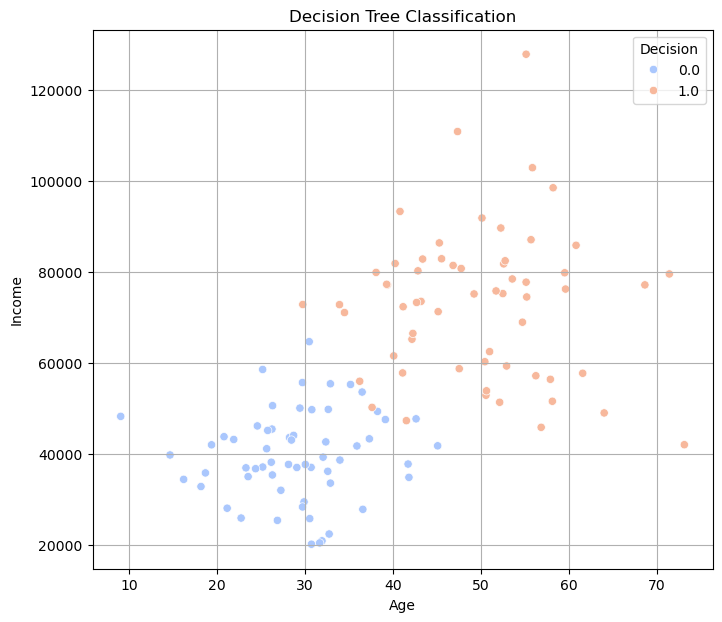

In [3]:
# Plot the generated data for Decision Tree
plt.figure(figsize=(8, 7))

sns.scatterplot(
    x='Age',
    y='Income',
    hue='Decision',
    data=df_dt,
    palette='coolwarm'
)

plt.title('Decision Tree Classification')
plt.xlabel('Age')
plt.ylabel('Income')
plt.grid()
plt.legend(title='Decision')
plt.show()

In [4]:
# Split data for Decision Tree
X_dt_train, X_dt_test, y_dt_train, y_dt_test = train_test_split(X_dt, y_dt, test_size=0.2, random_state=42)

print(f"Training set shape for DT: {X_dt_train.shape}, {y_dt_train.shape}")
print(f"Testing set shape for DT: {X_dt_test.shape}, {y_dt_test.shape}")

Training set shape for DT: (96, 2), (96,)
Testing set shape for DT: (24, 2), (24,)


In [5]:
# Initialize Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(max_depth=3, random_state=42)  # Limiting depth to 3 for better visualization and preventing overfitting

# Train the model
dt_classifier.fit(X_dt, y_dt)

print("Decision Tree classifier trained successfully.")

Decision Tree classifier trained successfully.


In [6]:
# Make predictions on the test data
y_dt_pred = dt_classifier.predict(X_dt_test)

print("First 10 actual labels for DT:", y_dt_test[:10])
print("First 10 predicted labels for DT:", y_dt_pred[:10])

First 10 actual labels for DT: [0. 0. 0. 0. 0. 1. 1. 0. 0. 1.]
First 10 predicted labels for DT: [0. 0. 0. 0. 0. 1. 1. 0. 0. 1.]


In [7]:
# Evaluate the Decision Tree model's performance
dt_accuracy = accuracy_score(y_dt_test, y_dt_pred)
dt_report = classification_report(y_dt_test, y_dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")
print("Decision Tree Classification Report:\n", dt_report)

Decision Tree Accuracy: 1.00
Decision Tree Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        13
         1.0       1.00      1.00      1.00        11

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24

